# 08 – Zufallszahlen

**Stochastische Signale** haben im Vorlesungskapitel **02 – Signale und Spektren** einen besonderen Stellenwert in der Kommunikationstechnik: Rauschen, Störungen und viele Zufallsprozesse werden mit Zufallszahlen modelliert. Python bietet Funktionen zur Erzeugung **gleichverteilter** und **normalverteilter** Zufallszahlen – zentral für die Modellierung von Rauschen und anderen Zufallsprozessen. Hier lernst du, wie du Zufallszahlen **gezielt** in Python erzeugst, welche **Verteilungen** eine Rolle spielen, und wie du die statistischen Eigenschaften mit **Histogrammen** (Matplotlib) sichtbar machst.

**Navigation:** [← 07_Komplexe_Zahlen](../07_Komplexe_Zahlen/07_Komplexe_Zahlen.ipynb) | 08_Zufallszahlen | [→ 09_Steuerung](../09_Steuerung/09_Steuerung.ipynb)

## Warum Zufallszahlen in der KT?

In der Nachrichtentechnik treten **stochastische Signale** überall auf: **Rauschen** (thermisches Rauschen, Quantisierungsrauschen), **Störungen**, **Kanalzustände**, **Bitfehler**. Um solche Prozesse zu simulieren oder zu analysieren, brauchst du **Zufallszahlen** mit bestimmten **statistischen Eigenschaften**. Zwei Verteilungen spielen dabei eine herausragende Rolle: die **Gleichverteilung** (z. B. für Phasen, Symbole) und die **Normalverteilung** (Gauß-Verteilung), die das Rauschen in vielen Fällen gut beschreibt.

## Gezielte Erzeugung: Seed für Reproduzierbarkeit

„Zufall" im Rechner ist **pseudozufällig**: Ein Algorithmus erzeugt eine Folge von Zahlen, die statistisch wie Zufall aussehen, aber bei gleichem **Startwert (Seed)** immer dieselbe Folge liefern. Das ist enorm nützlich: Du kannst Experimente **reproduzierbar** machen – z. B. für Debugging oder zum Vergleich von Verfahren.

- **Standardbibliothek `random`:** `random.seed(42)` – danach liefert `random.random()` etc. eine feste Folge.
- **NumPy:** `np.random.seed(42)` – danach liefern `np.random.rand()`, `np.random.randn()` etc. eine feste Folge.

In [1]:
import random
import numpy as np

random.seed(42)
print("random (Seed 42):", [random.random() for _ in range(3)])

np.random.seed(42)
print("numpy (Seed 42):", np.random.rand(3).tolist())

random (Seed 42): [0.6394267984578837, 0.025010755222666936, 0.27502931836911926]
numpy (Seed 42): [0.3745401188473625, 0.9507143064099162, 0.7319939418114051]


## Welche Verteilungen spielen eine Rolle?

| Verteilung | Bedeutung in der KT | Python / NumPy |
|------------|----------------------|----------------|
| **Gleichverteilung** | Symbole, Phasen, gleich wahrscheinliche Ereignisse; Basis für viele Simulationen | `random.random()`, `np.random.rand()`, `np.random.uniform(a, b)` |
| **Normalverteilung (Gauß)** | Rauschen (thermisch, additives weisses Gauß-Rauschen AWGN), Fehlerstatistik | `random.gauss(mu, sigma)`, `np.random.randn()`, `np.random.normal(mu, sigma, size)` |

Weitere Verteilungen (z. B. Exponential, Poisson) gibt es in NumPy bzw. `scipy.stats` – für die Grundlagen reichen Gleich- und Normalverteilung.

## Gleichverteilte Zufallszahlen

**Gleichverteilung (uniform):** Jeder Wert in einem Intervall ist gleich wahrscheinlich. Typisch: $[0, 1)$ oder $[a, b)$.

- `random.random()` – gleichverteilt in $[0, 1)$.
- `np.random.rand(n)` – $n$ gleichverteilte Zahlen in $[0, 1)$.
- `np.random.uniform(a, b, size)` – gleichverteilt in $[a, b)$.

In [2]:
import numpy as np

np.random.seed(123)
u = np.random.rand(1000)  # 1000 Zahlen in [0, 1)
print("Min:", u.min(), " Max:", u.max(), " Mittelwert (ca. 0.5):", u.mean())

Min: 8.188761366767494e-05  Max: 0.9989184059727976  Mittelwert (ca. 0.5): 0.4993730310402514


## Normalverteilte Zufallszahlen (Gauß)

**Normalverteilung:** Die klassische Verteilung für **Rauschen** – Mittelwert $\mu$, Standardabweichung $\sigma$. Viele Rauschprozesse sind näherungsweise gaußverteilt (zentraler Grenzwertsatz).

- `np.random.randn(n)` – Standard-Normalverteilung ($\mu=0$, $\sigma=1$), $n$ Werte.
- `np.random.normal(mu, sigma, size)` – Normalverteilung mit Mittelwert `mu` und Standardabweichung `sigma`.

In [3]:
import numpy as np

np.random.seed(456)
n = np.random.randn(1000)  # Standard-Normalverteilung
print("Mittelwert (ca. 0):", n.mean(), " Std (ca. 1):", n.std())

Mittelwert (ca. 0): 0.0003007691784666129  Std (ca. 1): 0.989468968605406


## Statistische Eigenschaften im Histogramm: Gleichverteilung

Mit einem **Histogramm** siehst du, wie oft Werte in welchen Bereichen vorkommen. Bei einer Gleichverteilung auf $[0, 1)$ erwarten wir eine annähernd **rechteckige** Form – alle Klassen etwa gleich häufig.

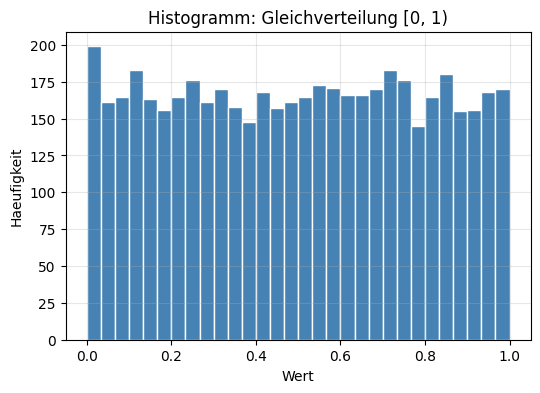

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)
u = np.random.rand(5000)

plt.figure(figsize=(6, 4))
plt.hist(u, bins=30, color="steelblue", edgecolor="white")
plt.xlabel("Wert")
plt.ylabel("Haeufigkeit")
plt.title("Histogramm: Gleichverteilung [0, 1)")
plt.grid(True, alpha=0.3)
plt.show()

## Statistische Eigenschaften im Histogramm: Normalverteilung

Bei der **Normalverteilung** erwarten wir eine **glockenförmige** Kurve: Werte um den Mittelwert herum am häufigsten, nach außen seltener. So kannst du z. B. Rauschen visuell prüfen.

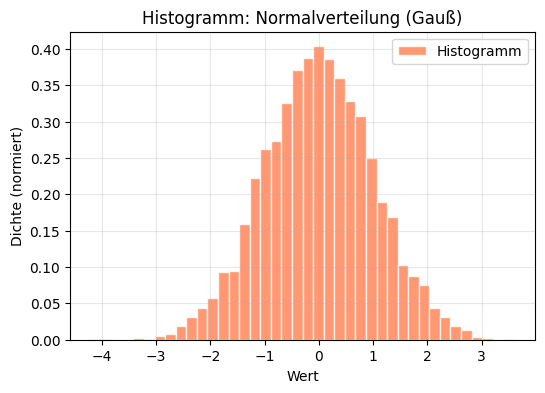

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(456)
n = np.random.randn(5000)

plt.figure(figsize=(6, 4))
plt.hist(n, bins=40, color="coral", edgecolor="white", density=True, alpha=0.8, label="Histogramm")
plt.xlabel("Wert")
plt.ylabel("Dichte (normiert)")
plt.title("Histogramm: Normalverteilung (Gauß)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Kurz zusammengefasst

| Thema | Inhalt |
|-------|--------|
| **Bezug KT** | Stochastische Signale in 02.Signale und Spektren; Rauschen, Zufallsprozesse; besonderer Stellenwert in der Kommunikationstechnik. |
| **Gezielte Erzeugung** | `random.seed(...)` bzw. `np.random.seed(...)` für reproduzierbare Folgen. |
| **Gleichverteilung** | `random.random()`, `np.random.rand()`, `np.random.uniform(a, b)`; für Symbole, Phasen, Basis-Simulationen. |
| **Normalverteilung** | `np.random.randn()`, `np.random.normal(mu, sigma)`; für Rauschen (z. B. AWGN), Fehlerstatistik. |
| **Statistik sichtbar machen** | **Histogramme** mit Matplotlib (`plt.hist`); Gleichverteilung ≈ rechteckig, Normalverteilung ≈ glockenförmig. |

Damit hast du das Handwerkszeug, um Rauschen und andere Zufallsprozesse in Python zu modellieren und ihre statistischen Eigenschaften mit Histogrammen zu überprüfen.

---

**Weiter:** [→ 09_Steuerung](../09_Steuerung/09_Steuerung.ipynb) – Bedingungen (`if`/`else`), Schleifen vertiefen.

**Zurück:** [← 07_Komplexe_Zahlen](../07_Komplexe_Zahlen/07_Komplexe_Zahlen.ipynb)